# Modèle 1 — Régression linéaire (degré 1)

**Objectif.** Construire le modèle le plus simple possible et mesurer honnêtement sa performance. Il sert de **référence** à tous les modèles suivants : un modèle plus complexe ne vaudra que s'il fait nettement mieux.

**Exécution.** Depuis la racine du projet, de haut en bas, après `data_preprocessing.ipynb`, qui produit `data/cleaned/cleaned.csv`. La figure prédit / réel est enregistrée dans `report/figures/`.

**Sommaire**
1. Le modèle et le protocole : 1.1 Pourquoi une régression linéaire · 1.2 Protocole d'évaluation
2. Les données : un sous-jeu par cible
3. Validation croisée : référence contre régression linéaire
4. Analyse : 4.1 Pourquoi pire que la moyenne ? · 4.2 Prédit contre réel · 4.3 Erreur par article · 4.4 Coefficients
5. Bilan et suite

# 1. Le modèle et le protocole

## 1.1 Pourquoi une régression linéaire

Le modèle prédit la cible comme une **somme pondérée des entrées** : ŷ = b + w₁x₁ + … + wₚxₚ. Les poids sont choisis pour minimiser l'erreur quadratique sur les données d'entraînement (moindres carrés).

- **Simple** : aucun hyperparamètre à régler, donc une validation croisée simple suffit.
- **Interprétable** : les entrées étant standardisées, un poids se lit comme « l'effet d'un écart-type de cette entrée, les autres restant fixes ».
- **Limites attendues** : uniquement des effets en ligne droite qui s'additionnent, sans saturation ni interaction (par exemple carbone × traitement thermique). Les poids d'entrées corrélées (courant, tension et énergie de soudage ; Cr, Mo et V) sont instables.

## 1.2 Protocole d'évaluation

- **Une cible à la fois** : 5 modèles indépendants. `get_xy` garde les lignes où la cible est mesurée et fusionne les doublons d'entrée (notebook de pré-processing, partie 4).
- **Validation croisée groupée par article** (`GroupKFold`, 5 plis) : toutes les lignes d'un article sont dans le même pli. Le score mesure donc la capacité à prédire les soudures **d'une étude jamais vue**, ce qui correspond à l'usage réel du modèle.
- **Sans fuite** : la préparation (médiane, standardisation, one-hot) est dans un `Pipeline` avec le modèle. Elle est réapprise sur la partie entraînement de chaque pli.
- **Prédictions hors pli** : chaque ligne est prédite une fois, par le modèle qui ne l'a pas vue. Les erreurs sont calculées sur l'ensemble de ces prédictions, pour que chaque ligne compte autant même si les plis n'ont pas la même taille. L'écart-type de la RMSE entre plis indique la stabilité.
- **Mesures d'erreur** :
  - **RMSE** = √(moyenne des (y − ŷ)²), dans l'unité de la cible ; elle pénalise fortement les grosses erreurs ;
  - **MAE** = moyenne des |y − ŷ|, l'erreur « typique » ;
  - **R²** = 1 − Σ(y − ŷ)² / Σ(y − ȳ)², la part de la variance expliquée : 0 signifie pas mieux que la moyenne, 1 parfait, et un R² négatif signifie pire que la moyenne.
- **Référence** : prédire la moyenne de l'entraînement (`DummyRegressor`). Tout modèle doit faire mieux.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.pipeline import Pipeline

sys.path.insert(0, "preprocessing")
from ml_dataset import TARGETS, get_xy, load_cleaned, make_preprocessor

FIGURES = Path("report/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
N_PLIS = 5
NOMS = {"yield": "Limite d'élasticité (MPa)", "uts": "Résistance à la traction (MPa)",
        "elongation": "Allongement (%)", "roa": "Striction (%)", "charpy": "Énergie Charpy (J)"}

# 2. Les données : un sous-jeu par cible

Pour chaque cible, `get_xy` renvoie X (25 entrées, 26 pour le Charpy avec la température d'essai), y, et l'article de chaque ligne (`groups`). L'écart-type de la cible donne l'ordre de grandeur de l'erreur de la référence : un modèle utile doit faire nettement moins.

In [2]:
df = load_cleaned()
donnees = {cible: get_xy(df, cible) for cible in TARGETS}
display(pd.DataFrame([
    {"cible": NOMS[c], "lignes": len(y), "articles": g.nunique(), "entrées": X.shape[1],
     "moyenne": round(y.mean(), 1), "écart-type": round(y.std(), 1)}
    for c, (X, y, g) in donnees.items()
]).set_index("cible"))

,lignes,articles,entrées,moyenne,écart-type
cible,,,,,
Limite d'élasticité (MPa),725,42,25,510.9,92.5
Résistance à la traction (MPa),682,41,25,595.7,88.5
Allongement (%),649,36,25,26.1,4.9
Striction (%),654,34,25,71.8,9.1
Énergie Charpy (J),850,26,26,86.7,48.9


# 3. Validation croisée : référence contre régression linéaire

`evaluer` applique le protocole 1.2 à un modèle et une cible : elle renvoie les prédictions hors pli et les mesures d'erreur. `regression_lineaire` assemble la préparation et les moindres carrés dans un seul `Pipeline`.

In [3]:
def evaluer(modele, X, y, groups, n_plis=N_PLIS):
    """Prédictions hors pli (GroupKFold par article) et mesures d'erreur."""
    cv = GroupKFold(n_splits=n_plis)
    pred = pd.Series(cross_val_predict(modele, X, y, groups=groups, cv=cv), index=y.index)
    rmse_plis = [mean_squared_error(y.iloc[test], pred.iloc[test]) ** 0.5
                 for _, test in cv.split(X, y, groups)]
    mesures = {
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "RMSE écart-type entre plis": np.std(rmse_plis),
        "MAE": mean_absolute_error(y, pred),
        "R²": r2_score(y, pred),
    }
    return pred, mesures


def regression_lineaire(X):
    """Préparation (réapprise dans chaque pli) + moindres carrés."""
    return Pipeline([("prep", make_preprocessor(X)), ("reg", LinearRegression())])


resultats, predictions = [], {}
for cible, (X, y, groups) in donnees.items():
    for nom, modele in [("référence (moyenne)", DummyRegressor()),
                        ("régression linéaire", regression_lineaire(X))]:
        pred, mesures = evaluer(modele, X, y, groups)
        resultats.append({"cible": NOMS[cible], "modèle": nom, **mesures})
        if nom == "régression linéaire":
            predictions[cible] = pred

tableau = pd.DataFrame(resultats).set_index(["cible", "modèle"])
display(tableau.round(2))

RMSE  \
cible                          modèle                        
Limite d'élasticité (MPa)      référence (moyenne)   93.24   
                               régression linéaire  123.31   
Résistance à la traction (MPa) référence (moyenne)   90.78   
                               régression linéaire  117.19   
Allongement (%)                référence (moyenne)    4.98   
                               régression linéaire    6.72   
Striction (%)                  référence (moyenne)    9.62   
                               régression linéaire   10.59   
Énergie Charpy (J)             référence (moyenne)   49.73   
                               régression linéaire   63.73   

                                                    RMSE écart-type entre plis  \
cible                          modèle                                            
Limite d'élasticité (MPa)      référence (moyenne)                       10.22   
                               régression linéaire                       31.51   
Résistance à la traction (MPa) référence (moyenne)                       10.68   
                               régression linéaire                       19.67   
Allongement (%)                référence (moyenne)                        0.64   
                               régression linéaire                        1.70   
Striction (%)                  référence (moyenne)                        2.39   
                               régression linéaire                        4.30   
Énergie Charpy (J)             référence (moyenne)                        6.23   
                               régression linéaire                       28.29   

                                                      MAE    R²  
cible                          modèle                            
Limite d'élasticité (MPa)      référence (moyenne)  71.94 -0.02  
                               régression linéaire  86.94 -0.78  
Résistance à la traction (MPa) référence (moyenne)  71.86 -0.05  
                               régression linéaire  89.82 -0.75  
Allongement (%)                référence (moyenne)   4.13 -0.03  
                               régression linéaire   5.21 -0.87  
Striction (%)                  référence (moyenne)   7.35 -0.13  
                               régression linéaire   6.59 -0.37  
Énergie Charpy (J)             référence (moyenne)  38.63 -0.04  
                               régression linéaire  44.31 -0.70

**Constat** : la régression linéaire fait **moins bien que la simple moyenne** pour les 5 cibles (R² négatifs, de −0,4 à −0,9), et sa RMSE varie beaucoup d'un pli à l'autre. Ce n'est pas un bug : la partie 4.1 l'explique.

# 4. Analyse

## 4.1 Pourquoi le modèle fait-il pire que la moyenne ?

On compare la même régression linéaire avec deux découpages :
- **aléatoire** (`KFold`) : des lignes d'un même article se retrouvent en entraînement et en test. Le modèle « connaît » déjà l'article testé : ce découpage mesure une interpolation et il est optimiste. Il sert ici **de diagnostic seulement** ;
- **par article** (`GroupKFold`, notre protocole) : l'article testé est entièrement nouveau.

Le R² sur les données apprises (entraînement sur toutes les lignes) est donné pour mémoire.

In [4]:
diagnostic = []
for cible, (X, y, groups) in donnees.items():
    r2_appris = r2_score(y, regression_lineaire(X).fit(X, y).predict(X))
    pred_aleatoire = cross_val_predict(regression_lineaire(X), X, y,
                                       cv=KFold(N_PLIS, shuffle=True, random_state=0))
    diagnostic.append({"cible": NOMS[cible],
                       "R² données apprises": r2_appris,
                       "R² découpage aléatoire": r2_score(y, pred_aleatoire),
                       "R² découpage par article": r2_score(y, predictions[cible])})
display(pd.DataFrame(diagnostic).set_index("cible").round(2))

,R² données apprises,R² découpage aléatoire,R² découpage par article
cible,,,
Limite d'élasticité (MPa),0.59,0.46,-0.78
Résistance à la traction (MPa),0.68,0.56,-0.75
Allongement (%),0.54,0.36,-0.87
Striction (%),0.73,0.67,-0.37
Énergie Charpy (J),0.61,0.54,-0.70


**Constat** : le modèle apprend bien quelque chose : R² de 0,54 à 0,73 sur les données apprises, de 0,36 à 0,67 avec un découpage aléatoire. Mais il **ne se transfère pas à un article inconnu**.

Chaque article a sa famille d'aciers, son laboratoire et ses conditions d'essai. Un article mis de côté tombe donc souvent en dehors du domaine couvert par les autres, et une droite prolongée hors de son domaine peut donner des valeurs absurdes.

C'est la principale difficulté du problème, et c'est exactement ce que le découpage par article doit révéler : un découpage aléatoire aurait laissé croire à un modèle correct.

## 4.2 Prédit contre réel

Chaque point est une ligne, prédite par le modèle qui ne l'a pas vue. Les points devraient s'aligner sur la diagonale : un nuage aplati signale un modèle qui prédit presque la moyenne, un écart systématique au-dessus ou au-dessous signale un biais.

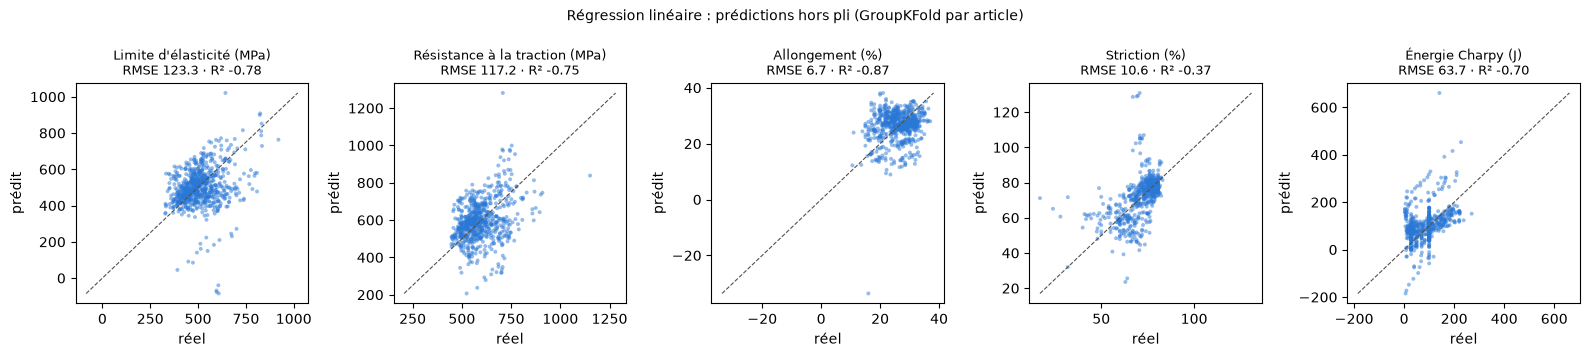

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, (cible, (X, y, groups)) in zip(axes, donnees.items()):
    pred = predictions[cible]
    ax.scatter(y, pred, s=8, alpha=0.5, color="#2a78d6", edgecolor="none")
    bornes = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(bornes, bornes, color="#52514e", linewidth=0.8, linestyle="--")
    m = tableau.loc[(NOMS[cible], "régression linéaire")]
    ax.set_title(f"{NOMS[cible]}\nRMSE {m['RMSE']:.1f} · R² {m['R²']:.2f}", fontsize=9)
    ax.set_xlabel("réel"); ax.set_ylabel("prédit")
fig.suptitle("Régression linéaire : prédictions hors pli (GroupKFold par article)", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "rl_predit_reel.pdf", bbox_inches="tight")
plt.show()

**Constat** : le nuage s'écarte nettement de la diagonale. Certaines prédictions sont même **physiquement impossibles**, comme une énergie Charpy, un allongement ou une limite d'élasticité négatifs : c'est la signature d'une droite prolongée loin des données d'entraînement.

## 4.3 Erreur par article

Le modèle se trompe-t-il partout un peu, ou beaucoup sur quelques articles ? Pour chaque cible, voici les 5 articles où l'erreur moyenne est la plus forte. Le **biais** est la moyenne de (réel − prédit) :
- **biais proche de ± MAE** : l'article est décalé d'un bloc, sans doute à cause d'une variable non mesurée (laboratoire, épaisseur, mode d'essai…) ou d'une recette hors du domaine des autres articles ;
- **biais proche de 0** : erreurs dispersées dans les deux sens.

In [6]:
lignes = []
for cible, (X, y, groups) in donnees.items():
    erreur = y - predictions[cible]
    par_article = pd.DataFrame({"lignes": erreur.groupby(groups).size(),
                                "MAE": erreur.abs().groupby(groups).mean(),
                                "biais": erreur.groupby(groups).mean()})
    for article, r in par_article.nlargest(5, "MAE").iterrows():
        lignes.append({"cible": NOMS[cible], "article": article, **r.to_dict()})
display(pd.DataFrame(lignes).set_index(["cible", "article"]).round(1))

lignes    MAE  biais
cible                          article                                   
Limite d'élasticité (MPa)      Natsume-1990             4.0  669.3  669.3
                               Ditt                     1.0  323.0  323.0
                               Inag&-1966               1.0  243.7 -243.7
                               RaiterGonzal-Mo-1989    18.0  212.0  204.9
                               SurianEtAl-C-1991        8.0  211.6  211.6
Résistance à la traction (MPa) Natsume-1990             4.0  373.4  373.4
                               Icici&-1992              6.0  208.3 -208.3
                               Inag&-1966               1.0  204.9 -204.9
                               Pat-1981                16.0  200.3 -200.3
                               SurianEtAl-C-1991        8.0  194.2  194.2
Allongement (%)                Natsume-1990             4.0   15.5  -15.5
                               RR82011                 23.0   14.3   14.3
                               RC81033                  4.0   13.9   13.9
                               Wolst-1974              23.0   12.6  -12.6
                               Mart                     7.0   10.2    4.0
Striction (%)                  Icici&-1992              8.0   30.9  -30.6
                               Pat-1981                16.0   19.6   19.6
                               Evans-Nb/Mn-1991        32.0   16.4  -16.4
                               Stil-TiB-1978           16.0   15.8   15.8
                               EPRI                     6.0   15.5   15.5
Énergie Charpy (J)             Ditt                     4.0  299.7 -299.7
                               Mart                    63.0  153.4 -112.7
                               Blond&-1984              6.0  100.2  100.2
                               Kluket-CuMnB-1994       12.0   58.9  -58.9
                               EvHtIp1979              16.0   52.1   48.2

**Constat** : les plus grosses erreurs viennent de quelques articles, presque toujours avec un **biais égal à la MAE** : l'article entier est décalé d'un bloc.

Plusieurs de ces articles ont très peu de lignes et portent sur des aciers alliés au chrome-molybdène, rares dans la base (`Natsume-1990`, `Inag&-1966`, `Ditt`). Le modèle extrapole alors loin de ses données d'entraînement.

Ces quelques articles suffisent à faire chuter le R². L'erreur médiane reste plus modérée : environ 64 MPa pour la limite d'élasticité.

## 4.4 Coefficients

Le modèle est maintenant entraîné **sur toutes les lignes** de chaque cible : ce n'est plus de l'évaluation, mais la lecture du modèle final. Les entrées étant standardisées, les poids des variables numériques sont comparables entre eux.

**Précautions de lecture :**
- **Entrées corrélées** (courant, tension et énergie de soudage ; Cr, Mo et V) : le modèle peut répartir l'effet entre elles de façon arbitraire, avec parfois des poids de signes opposés qui se compensent.
- **Colonnes one-hot et indicateurs « valeur manquante »** : redondants entre eux et avec la constante, leurs poids ne se lisent pas isolément. Un indicateur « valeur manquante » décrit d'ailleurs la façon dont l'article a été rédigé, pas la soudure.
- **Corrélation n'est pas causalité** : un poids décrit une tendance dans les données publiées, pas l'effet garanti d'un changement de recette.

In [7]:
def nom_court(colonne):
    """'col03_Manganese_concentration' -> 'Manganese', 'missingindicator_col06_...' -> 'manquant: Nickel'."""
    manquant = colonne.startswith("missingindicator_")
    nom = re.sub(r"^(missingindicator_)?col\d+_", "", colonne)
    nom = nom.replace("_concentration", "").replace("_", " ")
    return ("manquant : " if manquant else "") + nom


coefficients = {}
for cible, (X, y, groups) in donnees.items():
    modele = regression_lineaire(X).fit(X, y)
    noms = [nom_court(c) for c in modele.named_steps["prep"].get_feature_names_out()]
    coefficients[cible] = pd.Series(modele.named_steps["reg"].coef_, index=noms)

# Les 8 poids les plus forts en valeur absolue, parmi les variables numériques mesurées
# (hors indicateurs « valeur manquante » et colonnes one-hot, qui ne se lisent pas isolément)
categories = ("AC or DC", "Electrode polarity", "Type of weld")
top = {}
for cible, coef in coefficients.items():
    lisibles = coef[[not n.startswith("manquant") and not n.startswith(categories) for n in coef.index]]
    meilleurs = lisibles.reindex(lisibles.abs().sort_values(ascending=False).index)[:8]
    top[NOMS[cible]] = [f"{n} ({v:+.1f})" for n, v in meilleurs.items()]
display(pd.DataFrame(top, index=range(1, 9)))

,Limite d'élasticité (MPa),Résistance à la traction (MPa),Allongement (%),Striction (%),Énergie Charpy (J)
1,Molybdenum (+69.0),Molybdenum (+50.5),Molybdenum (-2.3),as welded (-5.4),Charpy temperature (+37.3)
2,Post weld heat treatment time (-43.2),Manganese (+39.0),Post weld heat treatment time (+2.1),Post weld heat treatment temperature (-5.0),Chromium (-27.7)
3,Post weld heat treatment temperature (-41.9),Voltage (-29.9),degassing 250C 14h (-2.0),Current (-4.9),Voltage (+26.3)
4,as welded (-41.7),Nickel (+25.4),Voltage (+1.4),degassing 250C 14h (-4.1),Post weld heat treatment time (+23.8)
5,Voltage (-36.2),Chromium (+23.1),Chromium (-1.4),Chromium (-4.0),Current (-19.8)
6,Manganese (+36.0),Post weld heat treatment time (-22.2),Niobium (-1.3),Silicon (-2.4),degassing 250C 14h (-17.2)
7,Vanadium (+30.7),Silicon (+21.7),Current (-1.2),Voltage (+2.3),Phosphorus (-16.3)
8,degassing 250C 14h (+26.9),Niobium (+16.7),Manganese (-1.2),Sulphur (-2.3),Heat input (-16.0)


**Constat** :
- **Plusieurs tendances sont cohérentes avec la métallurgie** :
  - le molybdène, le manganèse, le vanadium et le chrome augmentent la résistance ;
  - un traitement thermique plus long ou plus chaud la diminue (c'est l'effet du revenu) ;
  - l'énergie Charpy augmente avec la température d'essai (passage du comportement fragile au ductile).
- **D'autres poids montrent l'effet des entrées corrélées** :
  - « brut de soudage » (`as welded`) a un poids négatif sur la limite d'élasticité, alors qu'une soudure non revenue est en général plus résistante : cet indicateur et la température de traitement se partagent l'effet ;
  - pour le Charpy, la tension et le courant ont des poids de signes opposés.
- **Vu les R² négatifs de la partie 4.1, ces poids décrivent les données apprises**, et non des effets fiables sur une soudure nouvelle.

# 5. Bilan et suite

- **Résultat** : en validation croisée par article, la régression linéaire de degré 1 fait moins bien que la moyenne sur les 5 cibles. Elle apprend des tendances plausibles, mais extrapole mal vers les articles qui sortent du domaine des autres.
- **Ce que ça nous apprend sur le problème** : la difficulté principale est l'**hétérogénéité entre articles** (familles d'aciers, laboratoires), plus que le choix du modèle. Le découpage par article est exigeant, mais c'est lui qui correspond à l'usage réel.
- **Pistes, dans l'ordre** :
  1. **Régularisation** (Ridge, Lasso), réglée par validation croisée imbriquée, pour limiter les poids extrêmes qui explosent en extrapolation.
  2. **Modèles à base d'arbres** (forêts aléatoires, boosting) : leurs prédictions restent dans la plage des valeurs vues à l'entraînement, ce qui limite les erreurs absurdes.
  3. **Étudier le domaine couvert** : repérer les familles d'aciers rares (Cr-Mo, 9Cr-1Mo), parfois représentées par un ou deux articles, et décider s'il faut les traiter à part ou seulement les signaler.
  4. **Variables métier** (carbone équivalent, paramètre de Hollomon-Jaffe) et **sélection de variables**, toujours à l'intérieur de la validation croisée.